In [ ]:
import sys
import os
import pandas as pd
from src.data_loader import load_datasets, get_train_test_split

_root = os.path.join(os.path.dirname(os.path.abspath("__file__")), "..")
sys.path.insert(0, _root)
sys.path.insert(0, os.path.join(_root, "src"))

print("Loading datasets...")
lob_df, articles_df = load_datasets()
train_df, test_df = get_train_test_split()

print(f"Total articles: {len(articles_df)}")
print(f"Train set: {len(train_df)}")
print(f"Test set:  {len(test_df)}")
print(f"Unique LOBs in test: {test_df['lob_code_str'].nunique()}")
print("\nClass distribution (top 10 LOBs in test):")
print(test_df["lob_code_str"].value_counts().head(10))

Loading datasets...
Total articles: 20499
Train set: 17426
Test set:  3073
Unique LOBs in test: 99

Class distribution (top 10 LOBs in test):
lob_code_str
1002     301
3004     272
4009     232
2002     197
17001    145
3014     120
24001     88
6002      78
2001      74
1001      74
Name: count, dtype: int64


In [2]:
def compute_metrics(results_df: pd.DataFrame) -> dict:
    """
    results_df columns:
      article_code, true_lob, pred_lob_1, pred_lobs_top3 (list),
      pred_inventory_1, true_inventory, confidence_1, correct_top1, correct_top3
    """
    top1 = results_df["correct_top1"].mean()
    top3 = results_df["correct_top3"].mean()

    inventory_mask = results_df["correct_top1"]
    inv_acc = (
        (
            results_df.loc[inventory_mask, "pred_inventory_1"]
            == results_df.loc[inventory_mask, "true_inventory"]
        ).mean()
        if inventory_mask.sum() > 0
        else float("nan")
    )

    mean_conf_correct = results_df.loc[
        results_df["correct_top1"], "confidence_1"
    ].mean()
    mean_conf_wrong = results_df.loc[~results_df["correct_top1"], "confidence_1"].mean()

    return {
        "top1_accuracy": round(top1, 4),
        "top3_accuracy": round(top3, 4),
        "inventory_accuracy_when_top1_correct": round(inv_acc, 4)
        if inv_acc == inv_acc
        else None,
        "mean_confidence_correct": round(mean_conf_correct, 4)
        if mean_conf_correct == mean_conf_correct
        else None,
        "mean_confidence_incorrect": round(mean_conf_wrong, 4)
        if mean_conf_wrong == mean_conf_wrong
        else None,
    }

In [3]:
from tqdm import tqdm
from src.graph import classify_article
from src.vectorstore_setup import initialize_vectorstore
from src.data_loader import load_datasets, get_train_test_split

# Initialize vectorstore (skips if already built)
lob_df, _ = load_datasets()
train_df, test_df = get_train_test_split()
print(len(train_df), len(test_df))
initialize_vectorstore(train_df, lob_df)

SAMPLE_SIZE = 100
SAVE_EVERY = 10
RESULTS_PATH = "eval_results.csv"

sample = test_df.sample(n=min(SAMPLE_SIZE, len(test_df)), random_state=42)

records = []
for i, (_, row) in enumerate(tqdm(sample.iterrows(), total=len(sample))):
    code = row["codice_articolo"]
    true_lob = row["lob_code_str"]
    true_inv = row["inventario"]

    try:
        result = classify_article(code)
        print(result)
        suggestions = result.get("suggestions", [])

        pred_lob_1 = suggestions[0]["lob_code"] if suggestions else None
        pred_inv_1 = suggestions[0]["inventory"] if suggestions else None
        confidence_1 = suggestions[0]["confidence"] if suggestions else 0.0
        pred_lobs_top3 = [s["lob_code"] for s in suggestions[:3]]
    except Exception as exc:
        print(exc)
        pred_lob_1, pred_inv_1, confidence_1, pred_lobs_top3 = None, None, 0.0, []

    records.append(
        {
            "article_code": code,
            "true_lob": true_lob,
            "true_inventory": true_inv,
            "pred_lob_1": pred_lob_1,
            "pred_inventory_1": pred_inv_1,
            "confidence_1": confidence_1,
            "pred_lobs_top3": pred_lobs_top3,
            "correct_top1": pred_lob_1 == true_lob,
            "correct_top3": true_lob in pred_lobs_top3,
        }
    )

    if (i + 1) % SAVE_EVERY == 0:
        pd.DataFrame(records).to_csv(RESULTS_PATH, index=False)
        print(f"Saved {i + 1} results to {RESULTS_PATH}")

results_df = pd.DataFrame(records)
results_df.to_csv(RESULTS_PATH, index=False)
print(f"Evaluation complete. {len(results_df)} articles evaluated.")

17426 3073


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Vectorstore already populated — skipping embedding.


  0%|          | 0/100 [00:00<?, ?it/s]

[timing] db_lookup: 0.06s
[timing] web_enrichment: 25.86s


...

[rag_classification] step timings (s):
  A_build_query          0.000s
  B1_get_collections     0.003s
  B2_embed_query         0.030s
  B3_vector_search       0.138s
  CD_build_context       0.000s
  EF_llm_call            48.556s
  G_confidence           0.000s
  TOTAL                  48.727s
[timing] rag_classification: 48.73s

{'article_code': 'C9200L-48T-4G-E', 'article_description': 'Catalyst 9200L 48-port data, 4 x 1G, Network Essentials', 'existing_lob': '2002 - APPARATI CISCO LAN', 'existing_inventory': 'Inventario', 'web_enrichment': 'VENDOR: Cisco  \nAREA FUNZIONALE: networking LAN/WAN/Wireless  \nSOTTO-FUNZIONE: switch  \nFORMA: hardware fisico  \nNATURA COMMERCIALE: nuovo acquisto  \nRUOLO: prodotto autonomo  \nRILEVANZA INVENTARIALE: durevole/cespite (vita utile tipica 5-10 anni)', 'suggestions': [{'rank': 1, 'lob_code': '2002', 'lob_name': 'APPARATI CISCO LAN', 'inventory': 'Inventario', 'explanation': "L'articolo è un switch LAN Cisco (Catalyst 9200L) con funzionalità 

 99%|█████████▉| 99/100 [2:48:32<01:25, 85.39s/it]

[rag_classification] step timings (s):
  A_build_query          0.000s
  B1_get_collections     0.004s
  B2_embed_query         0.033s
  B3_vector_search       0.139s
  CD_build_context       0.000s
  EF_llm_call            45.824s
  G_confidence           0.000s
  TOTAL                  46.001s
[timing] rag_classification: 46.00s

{'article_code': 'HPE-EOSL-96-ISS', 'article_description': '570103-421', 'existing_lob': '3004 - CLOUD VARIE HW', 'existing_inventory': 'Non in inventario', 'web_enrichment': 'CHIAVE: VENDOR / BRAND principale: HP  \nCHIAVE: AREA FUNZIONALE: data center / server / storage  \nCHIAVE: SOTTO-FUNZIONE: server  \nCHIAVE: FORMA del bene: hardware fisico  \nCHIAVE: NATURA COMMERCIALE: nuovo acquisto  \nCHIAVE: RILEVANZA INVENTARIALE: durevole/cespite (vita utile: 5 anni)  \nCHIAVE: RUOLO nel sistema: prodotto autonomo', 'suggestions': [{'rank': 1, 'lob_code': '2005', 'lob_name': 'APPARATI HP', 'inventory': 'Inventario', 'explanation': "L'articolo è un dispositivo h

100%|██████████| 100/100 [2:50:11<00:00, 102.12s/it]

[rag_classification] step timings (s):
  A_build_query          0.000s
  B1_get_collections     0.004s
  B2_embed_query         0.033s
  B3_vector_search       0.009s
  CD_build_context       0.000s
  EF_llm_call            65.919s
  G_confidence           0.000s
  TOTAL                  65.965s
[timing] rag_classification: 65.97s

{'article_code': 'FTS:HP08NS20SE1379', 'article_description': 'OS,9x5,NBD Rt s/n YMBQ004361', 'existing_lob': '3004 - CLOUD VARIE HW', 'existing_inventory': 'Inventario', 'web_enrichment': 'VENDOR: Fujitsu  \nAREA FUNZIONALE: servizi gestiti / outsourcing  \nSOTTO-FUNZIONE: contratto di supporto vendor  \nFORMA DEL BENE: servizio professionale  \nNATURA COMMERCIALE: rinnovo  \nDURATA / TERMINE CONTRATTUALE: 3 anni  \nRILEVANZA INVENTARIALE: servizio  \nRUOLO NEL SISTEMA: componente', 'suggestions': [{'rank': 1, 'lob_code': '3036', 'lob_name': 'RINNOVO STORAGE HITACHI', 'inventory': 'Non in inventario', 'explanation': "Il prodotto rappresenta un rinnovo di un

In [4]:
metrics = compute_metrics(results_df)
summary = pd.DataFrame([metrics]).T
summary.columns = ["value"]
print("=== EVALUATION SUMMARY ===")
print(summary.to_string())

=== EVALUATION SUMMARY ===
                                       value
top1_accuracy                         0.3700
top3_accuracy                         0.4600
inventory_accuracy_when_top1_correct  0.8649
mean_confidence_correct               0.9197
mean_confidence_incorrect             0.6619


Top 10 confused LOB pairs (true → predicted):
pair
4008 → 2002     2
2001 → 2002     2
6003 → 6012     1
24001 → 6004    1
4015 → 4008     1
3014 → 3022     1
24001 → 1012    1
3002 → 3031     1
24002 → 1011    1
1006 → 4002     1

--- Example incorrect classifications ---
Article: OS01137233
  True LOB: 6003, Predicted: 6012, Confidence: 0.975
Article: SP-PSU-4A
  True LOB: 24001, Predicted: 6004, Confidence: 0.698
Article: L-SX-SERIES-PAK
  True LOB: 4008, Predicted: 2002, Confidence: 0.425
Article: A-MST-CVI-RMS-ENT
  True LOB: 4015, Predicted: 4008, Confidence: 0.900
Article: SW-FBRCP-SUBS-C190
  True LOB: 3014, Predicted: 3022, Confidence: 0.925


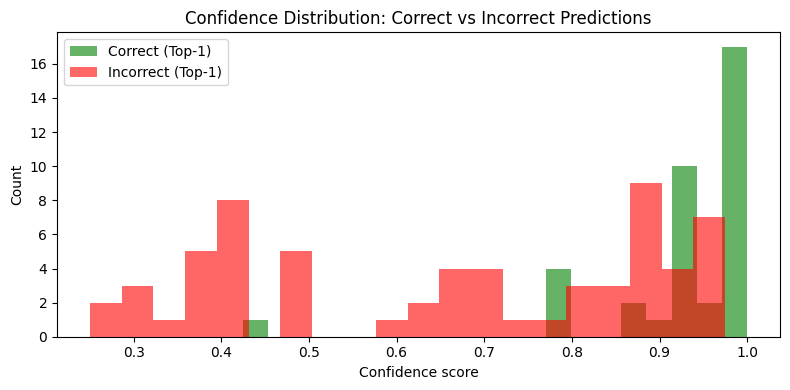

Saved: confidence_distribution.png


In [5]:
import matplotlib.pyplot as plt

# Top 10 confusion pairs
error_df = results_df[~results_df["correct_top1"]].copy()
if len(error_df) > 0:
    error_df["pair"] = (
        error_df["true_lob"] + " → " + error_df["pred_lob_1"].fillna("None")
    )
    top_confusions = error_df["pair"].value_counts().head(10)
    print("Top 10 confused LOB pairs (true → predicted):")
    print(top_confusions.to_string())
else:
    print("No errors to analyze.")

# Example incorrect classifications
print("\n--- Example incorrect classifications ---")
for _, row in error_df.head(5).iterrows():
    print(f"Article: {row['article_code']}")
    print(
        f"  True LOB: {row['true_lob']}, Predicted: {row['pred_lob_1']}, Confidence: {row['confidence_1']:.3f}"
    )

# Confidence distribution histogram
fig, ax = plt.subplots(figsize=(8, 4))
correct_conf = results_df.loc[results_df["correct_top1"], "confidence_1"]
wrong_conf = results_df.loc[~results_df["correct_top1"], "confidence_1"]
ax.hist(correct_conf, bins=20, alpha=0.6, label="Correct (Top-1)", color="green")
ax.hist(wrong_conf, bins=20, alpha=0.6, label="Incorrect (Top-1)", color="red")
ax.set_xlabel("Confidence score")
ax.set_ylabel("Count")
ax.set_title("Confidence Distribution: Correct vs Incorrect Predictions")
ax.legend()
plt.tight_layout()
plt.savefig("confidence_distribution.png", dpi=100)
plt.show()
print("Saved: confidence_distribution.png")

In [6]:
lob_stats = (
    results_df.groupby("true_lob")
    .agg(
        n_samples=("correct_top1", "count"),
        top1_acc=("correct_top1", "mean"),
        top3_acc=("correct_top3", "mean"),
    )
    .reset_index()
    .sort_values("top1_acc")
)

# Join LOB names
lob_names = lob_df[["LOB Code", "Name"]].rename(columns={"LOB Code": "true_lob"})
lob_names["true_lob"] = lob_names["true_lob"].astype(str)
lob_stats = lob_stats.merge(lob_names, on="true_lob", how="left")

print("Per-LOB accuracy (worst first):")
print(
    lob_stats[["true_lob", "Name", "n_samples", "top1_acc", "top3_acc"]].to_string(
        index=False
    )
)

Per-LOB accuracy (worst first):
true_lob                            Name  n_samples  top1_acc  top3_acc
    1001              CABLAGGI COMMSCOPE          2  0.000000  0.000000
    6003       TREND MICRO PRIMA VENDITA          2  0.000000  0.000000
    4015    CISCO COLLABORATION A CANONE          1  0.000000  0.000000
    4007     INSTALLAZIONE COLLABORATION          2  0.000000  0.000000
    4005                ROUTER TELEFONIA          1  0.000000  1.000000
    4004              TELEFONIA SOFTWARE          3  0.000000  0.000000
    3039                          RUBRIK          2  0.000000  0.000000
    3035                 STORAGE HITACHI          1  0.000000  0.000000
    3009                    SERVER CISCO          3  0.000000  0.000000
   99001                             NaN          1  0.000000  0.000000
    3002              SOFTWARE MICROSOFT          1  0.000000  1.000000
   24002                             NaN          2  0.000000  0.000000
   24001                        

In [7]:
from src.state import AgentState
from src.nodes.rag_classification import rag_classification_node
from src.data_loader import load_datasets


def classify_article_no_web(article_code: str) -> dict:
    """Classification pipeline without web enrichment (Node 2 skipped)."""
    _, articles_df = load_datasets()
    from src.data_loader import get_article_info

    article_info = get_article_info(article_code, articles_df)

    if article_info is None:
        return {"article_code": article_code, "suggestions": [], "error": "not found"}

    state: AgentState = {
        "article_code": article_code,
        "article_info": article_info,
        "web_enrichment": "",
        "retrieval_results": [],
        "classification": [],
        "error": None,
    }

    rag_result = rag_classification_node(state)
    return {
        "article_code": article_code,
        "suggestions": rag_result.get("classification", []),
        "error": rag_result.get("error"),
    }


# Run no-web evaluation on same sample
records_no_web = []
for i, (_, row) in enumerate(tqdm(sample.iterrows(), total=len(sample))):
    code = row["codice_articolo"]
    true_lob = row["lob_code_str"]
    true_inv = row["inventario"]

    try:
        result = classify_article_no_web(code)
        suggestions = result.get("suggestions", [])
        pred_lob_1 = suggestions[0]["lob_code"] if suggestions else None
        pred_inv_1 = suggestions[0]["inventory"] if suggestions else None
        confidence_1 = suggestions[0]["confidence"] if suggestions else 0.0
        pred_lobs_top3 = [s["lob_code"] for s in suggestions[:3]]
    except Exception:
        pred_lob_1, pred_inv_1, confidence_1, pred_lobs_top3 = None, None, 0.0, []

    records_no_web.append(
        {
            "article_code": code,
            "true_lob": true_lob,
            "true_inventory": true_inv,
            "pred_lob_1": pred_lob_1,
            "pred_inventory_1": pred_inv_1,
            "confidence_1": confidence_1,
            "pred_lobs_top3": pred_lobs_top3,
            "correct_top1": pred_lob_1 == true_lob,
            "correct_top3": true_lob in pred_lobs_top3,
        }
    )

results_no_web_df = pd.DataFrame(records_no_web)
metrics_no_web = compute_metrics(results_no_web_df)

print("=== WITH WEB ENRICHMENT ===")
for k, v in metrics.items():
    print(f"  {k}: {v}")

print("\n=== WITHOUT WEB ENRICHMENT ===")
for k, v in metrics_no_web.items():
    print(f"  {k}: {v}")

  1%|          | 1/100 [01:00<1:40:07, 60.69s/it]

[rag_classification] step timings (s):
  A_build_query          0.000s
  B1_get_collections     0.001s
  B2_embed_query         0.032s
  B3_vector_search       0.012s
  CD_build_context       0.000s
  EF_llm_call            60.637s
  G_confidence           0.000s
  TOTAL                  60.682s


  2%|▏         | 2/100 [01:52<1:30:46, 55.58s/it]

[rag_classification] step timings (s):
  A_build_query          0.000s
  B1_get_collections     0.002s
  B2_embed_query         0.023s
  B3_vector_search       0.007s
  CD_build_context       0.000s
  EF_llm_call            51.965s
  G_confidence           0.000s
  TOTAL                  51.997s


  3%|▎         | 3/100 [02:53<1:33:28, 57.82s/it]

...

[rag_classification] step timings (s):
  A_build_query          0.000s
  B1_get_collections     0.001s
  B2_embed_query         0.020s
  B3_vector_search       0.007s
  CD_build_context       0.000s
  EF_llm_call            37.299s
  G_confidence           0.000s
  TOTAL                  37.328s


 99%|█████████▉| 99/100 [3:01:56<00:51, 51.52s/it]

[rag_classification] step timings (s):
  A_build_query          0.000s
  B1_get_collections     0.002s
  B2_embed_query         0.024s
  B3_vector_search       0.008s
  CD_build_context       0.000s
  EF_llm_call            51.869s
  G_confidence           0.000s
  TOTAL                  51.904s


100%|██████████| 100/100 [3:02:52<00:00, 109.72s/it]

[rag_classification] step timings (s):
  A_build_query          0.000s
  B1_get_collections     0.001s
  B2_embed_query         0.024s
  B3_vector_search       0.007s
  CD_build_context       0.000s
  EF_llm_call            55.302s
  G_confidence           0.000s
  TOTAL                  55.334s
=== WITH WEB ENRICHMENT ===
  top1_accuracy: 0.37
  top3_accuracy: 0.46
  inventory_accuracy_when_top1_correct: 0.8649
  mean_confidence_correct: 0.9197
  mean_confidence_incorrect: 0.6619

=== WITHOUT WEB ENRICHMENT ===
  top1_accuracy: 0.46
  top3_accuracy: 0.52
  inventory_accuracy_when_top1_correct: 0.9783
  mean_confidence_correct: 0.9045
  mean_confidence_incorrect: 0.6105
